In [1]:
import pandas as pd

pd.read_csv("results_random_reaction_holdout_split_multi_modal_fusion.csv")

,model,mode,fold,split,accuracy_esi,precision_esi,recall_esi,f1_esi,roc_auc_esi,mcc_esi,cm_esi,accuracy_reaction_catalysis,precision_reaction_catalysis,recall_reaction_catalysis,f1_reaction_catalysis,roc_auc_reaction_catalysis,mcc_reaction_catalysis,cm_reaction_catalysis
0,random_reaction_holdout,TL,0,train,0.974080,0.960124,0.987175,0.973462,0.974545,0.948491,[[111991 4434]\n [ 1387 106762]],0.980746,0.970337,0.990291,0.980213,0.981085,0.961656,[[113151 3274]\n [ 1050 107099]]
1,random_reaction_holdout,TL,0,validation,0.620488,0.856480,0.306459,0.451402,0.626560,0.327740,[[51629 2909]\n [39287 17360]],0.635598,0.893075,0.323495,0.474950,0.641633,0.365033,[[52344 2194]\n [38322 18325]]
2,random_reaction_holdout,TL,0,test,0.677120,0.904077,0.443195,0.594805,0.694577,0.441360,[[39087 2233]\n [26441 21046]],0.667256,0.923902,0.411628,0.569518,0.686332,0.436339,[[39710 1610]\n [27940 19547]]


# Random split 

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("results_all_esi.csv")

# Define metrics of interest
metrics = ['accuracy', 'precision', 'recall', 'f1']

# Filter for the test set only
test_df = df[df['split'] == 'test']

# Melt the dataframe to have metrics in a single column
melted_df = test_df.melt(id_vars=['model', 'mode'], value_vars=metrics, 
                         var_name='metric', value_name='score')

# Create a facet grid where each row is a different model
g = sns.catplot(
    x='metric', y='score', hue='mode', col='model', 
    data=melted_df, kind='bar', height=5, aspect=1.5, palette='Set2', ci='sd',
    col_wrap=2  # Adjust this based on the number of models you have
)

# Add a horizontal line at 0.5 to represent random classifier performance
for ax in g.axes.flat:
    ax.axhline(y=0.5, color='red', linestyle='--')
    ax.text(0, 0.5, 'Random', color='red', ha='right', va='top')
    ax.set_ylim(0, 1)  # Ensure consistent y-axis limits for comparison

# Title and labels
g.fig.suptitle('Performance Metrics in Test', y=1.05)
g.set_axis_labels('Metric', 'Score')
g.set_titles(col_template='{col_name}')

# Rotate x labels for better readability
plt.xticks(rotation=45)

# Show plot
plt.show()


KeyError: "The following 'value_vars' are not present in the DataFrame: ['accuracy', 'f1', 'precision', 'recall']"

/tmp/ipykernel_122529/3137575011.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(


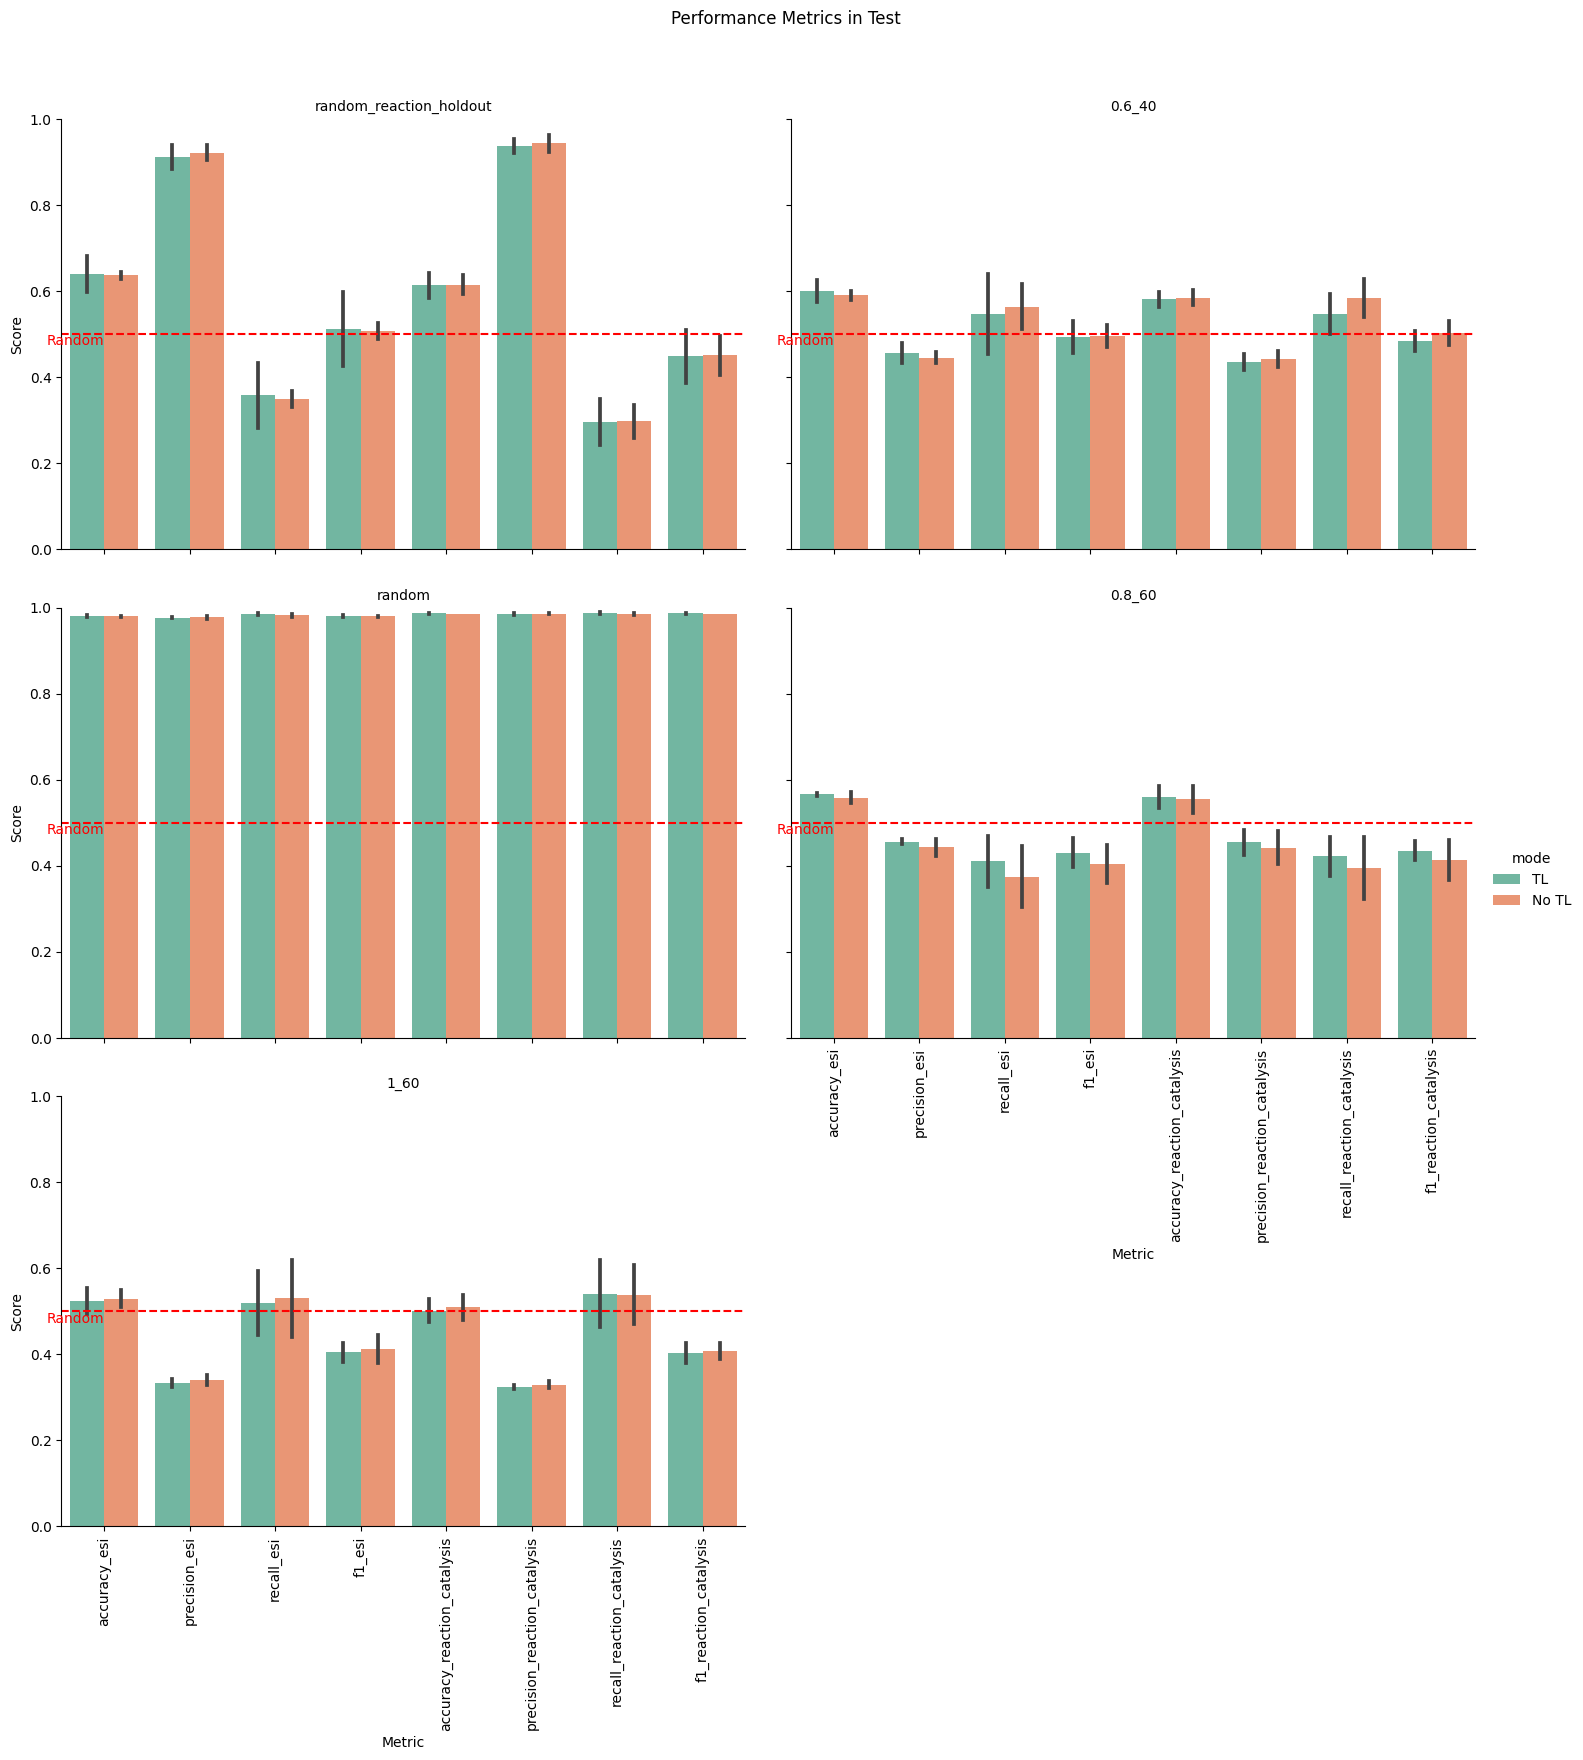

In [31]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("results_all_multi_modal_fusion.csv")

# Define metrics of interest
metrics = ['accuracy_esi', 'precision_esi', 'recall_esi', 'f1_esi',
           'accuracy_reaction_catalysis', 'precision_reaction_catalysis',
           'recall_reaction_catalysis', 'f1_reaction_catalysis']

# Filter for the test set only
test_df = df[df['split'] == 'test']

# Melt the dataframe to have metrics in a single column
melted_df = test_df.melt(id_vars=['model', 'mode'], value_vars=metrics, 
                         var_name='metric', value_name='score')

# Create a facet grid where each row is a different model
g = sns.catplot(
    x='metric', y='score', hue='mode', col='model', 
    data=melted_df, kind='bar', height=5, aspect=1.5, palette='Set2',   ci='sd',
    col_wrap=2  # Adjust this based on the number of models you have
)

# Add a horizontal line at 0.5 to represent random classifier performance
for ax in g.axes.flat:
    ax.axhline(y=0.5, color='red', linestyle='--')
    ax.text(0, 0.5, 'Random', color='red', ha='right', va='top')
    ax.set_ylim(0, 1)  # Ensure consistent y-axis limits for comparison
    ax.xaxis.set_tick_params(rotation=90)

# Title and labels
g.fig.suptitle('Performance Metrics in Test', y=1.05)
g.set_axis_labels('Metric', 'Score')
g.set_titles(col_template='{col_name}')


# Show plot
plt.show()


/tmp/ipykernel_1219585/2557204314.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(


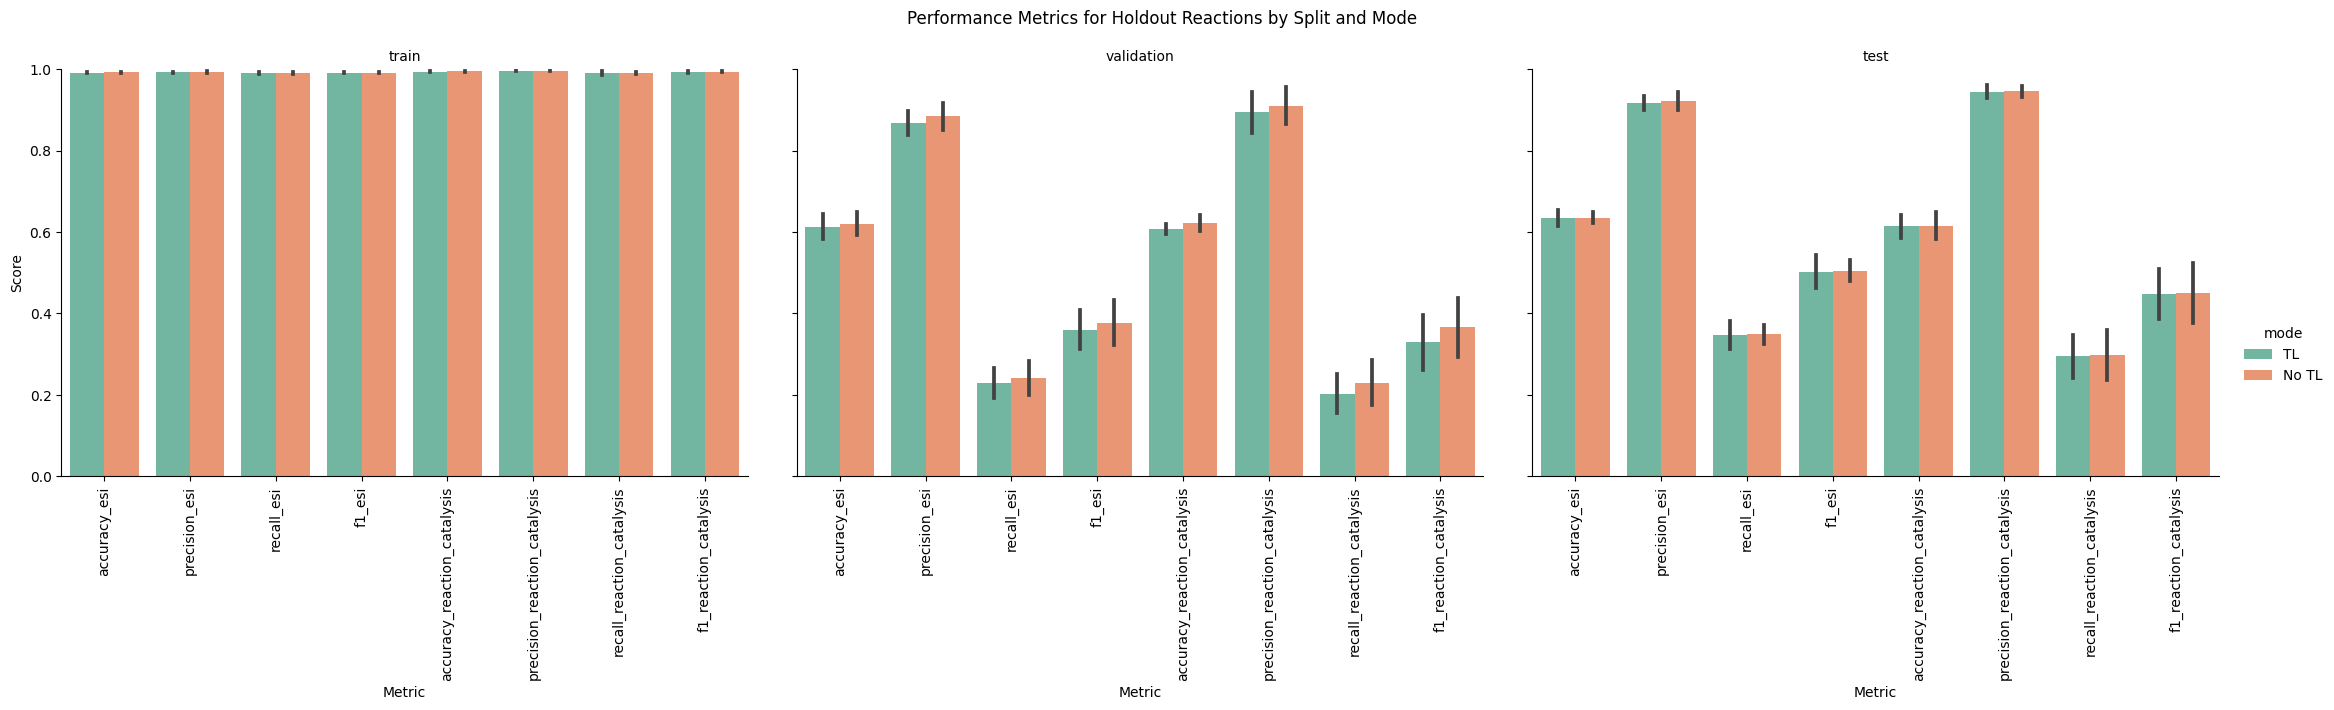

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

def plot_metrics_for_model(df, model_name):
    """
    This function filters the data for the given model and plots the metrics
    for different modes and splits (train, validation, test) within the same plot.

    Parameters:
    df (DataFrame): The dataframe containing the results.
    model_name (str): The name of the model to filter and plot.
    """

    # Define metrics of interest
    metrics = ['accuracy_esi', 'precision_esi', 'recall_esi', 'f1_esi',
               'accuracy_reaction_catalysis', 'precision_reaction_catalysis',
               'recall_reaction_catalysis', 'f1_reaction_catalysis']

    # Filter the dataframe for the selected model
    model_df = df[df['model'] == model_name]

    # Melt the dataframe to have metrics in a single column
    melted_df = model_df.melt(id_vars=['mode', 'split'], value_vars=metrics, 
                              var_name='metric', value_name='score')

    # Create a facet grid with different columns for each split and use hue for mode
    g = sns.catplot(
        x='metric', y='score', hue='mode', col='split',
        data=melted_df, kind='bar', height=5, aspect=1.5, palette='Set2', ci='sd'
    )

    # Add a horizontal line at 0.5 to represent random classifier performance
    for ax in g.axes.flat:
        ax.set_ylim(0, 1)  # Ensure consistent y-axis limits for comparison
        ax.xaxis.set_tick_params(rotation=90)

    # Title and labels
    g.fig.suptitle(f'Performance Metrics for {model_name} by Split and Mode', y=1.05)
    g.set_axis_labels('Metric', 'Score')
    g.set_titles(col_template='{col_name}')

    # Show plot
    plt.show()

# Usage example:
# Load the data
df = pd.read_csv("results_all_multi_modal_fusion.csv")

df.replace('random_reaction_holdout', 'Holdout Reactions', inplace=True)

# Call the function for a specific model
plot_metrics_for_model(df, model_name='Holdout Reactions')


In [3]:
def random_classifier_metrics(pos_count, neg_count):
    """
    Computes expected accuracy, F1 score, recall, and precision for a random classifier
    based on the counts of positive and negative classes in the data.
    
    Parameters:
    pos_count (int): Number of positive examples in the dataset
    neg_count (int): Number of negative examples in the dataset
    
    Returns:
    dict: A dictionary containing accuracy, f1 score, recall, and precision
    """
    
    # Total number of examples
    total_count = pos_count + neg_count
    
    # Probability of randomly guessing positive or negative
    prob_positive = pos_count / total_count
    prob_negative = neg_count / total_count
    
    # Expected true positives and true negatives for a random classifier
    expected_tp = prob_positive * pos_count
    expected_tn = prob_negative * neg_count
    
    # Expected false positives and false negatives for a random classifier
    expected_fp = prob_negative * pos_count
    expected_fn = prob_positive * neg_count
    
    # Precision: tp / (tp + fp)
    precision = expected_tp / (expected_tp + expected_fp) if (expected_tp + expected_fp) > 0 else 0
    
    # Recall: tp / (tp + fn)
    recall = expected_tp / (expected_tp + expected_fn) if (expected_tp + expected_fn) > 0 else 0
    
    # F1 Score: 2 * (precision * recall) / (precision + recall)
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Accuracy: (tp + tn) / total_count
    accuracy = (expected_tp + expected_tn) / total_count
    
    return {
        'accuracy': accuracy,
        'f1_score': f1_score,
        'recall': recall,
        'precision': precision
    }

test = pd.read_csv("../splits/random_reaction_holdout/test_dataset.csv")
pos_count = test['interaction'].value_counts()[1]
neg_count = test['interaction'].value_counts()[0]
random_classifier_metrics(pos_count, neg_count)


/tmp/ipykernel_3955460/3701039690.py:48: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv("../splits/random_reaction_holdout/test_dataset.csv")


{'accuracy': 0.5024111459658801,
 'f1_score': 0.5347213620547929,
 'recall': 0.5347213620547929,
 'precision': 0.5347213620547929}

<Axes: title={'center': 'Class Distribution in Test Set'}>

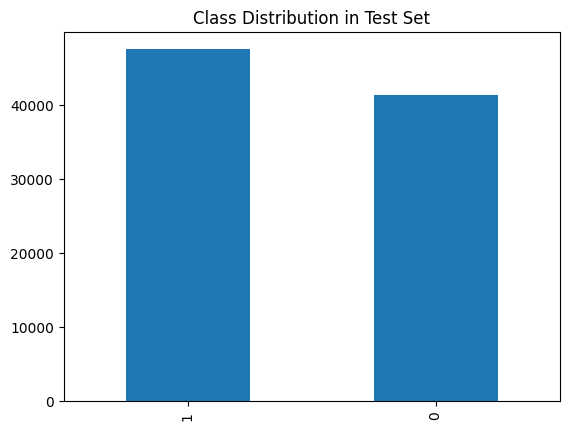

In [5]:
test['interaction'].value_counts().plot(kind='bar', title='Class Distribution in Test Set')

In [4]:
test = pd.read_csv("../splits/0.6_40/test_dataset.csv")
pos_count = test['interaction'].value_counts()[1]
neg_count = test['interaction'].value_counts()[0]
random_classifier_metrics(pos_count, neg_count) 

{'accuracy': 0.5392, 'f1_score': 0.36, 'recall': 0.36, 'precision': 0.36}

<Axes: title={'center': 'Class Distribution in Test Set'}>

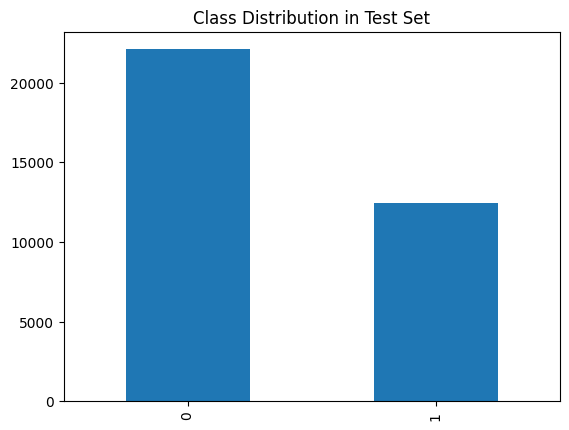

In [5]:
test['interaction'].value_counts().plot(kind='bar', title='Class Distribution in Test Set')

/tmp/ipykernel_1219585/2557204314.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(


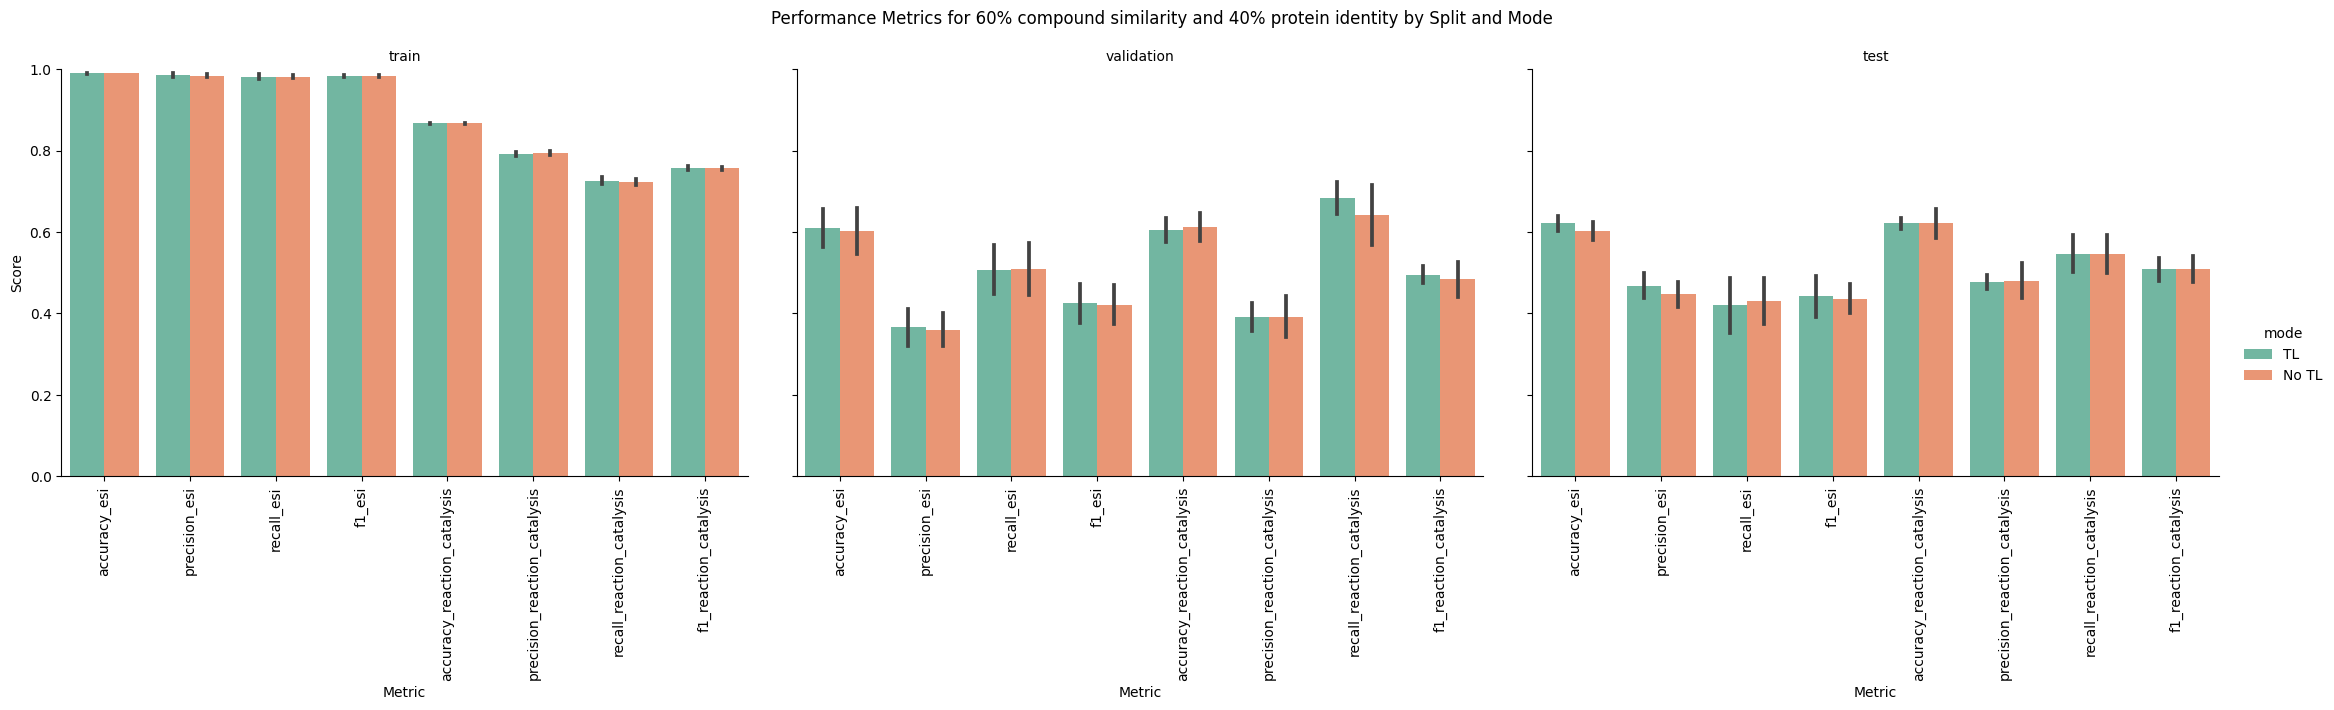

In [2]:
df.replace('0.6_40', r'60% compound similarity and 40% protein identity', inplace=True)

plot_metrics_for_model(df, model_name=r'60% compound similarity and 40% protein identity')

<Axes: title={'center': 'Test Dataset Interaction Distribution'}>

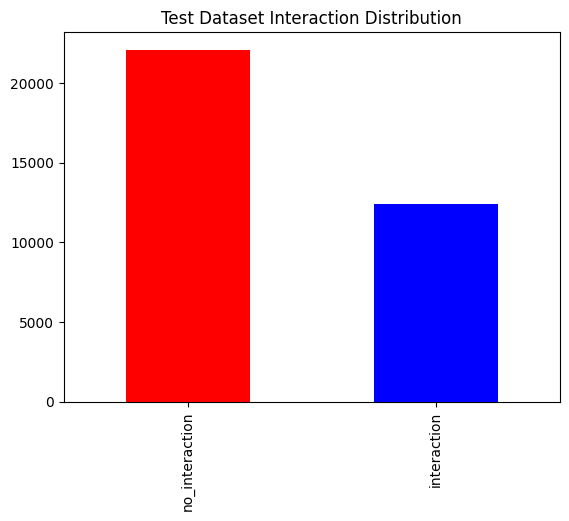

In [4]:
test = pd.read_csv("../splits/0.6_40/test_dataset.csv")

test['interaction'] = test['interaction'].replace({0: 'no_interaction', 1: 'interaction'})
value_counts = test['interaction'].value_counts()
# put the no interaction first
value_counts = value_counts.reindex(index=['no_interaction', 'interaction'])
value_counts.plot(kind='bar', color=['red', 'blue'], title='Test Dataset Interaction Distribution')

/tmp/ipykernel_3930252/3009219491.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(


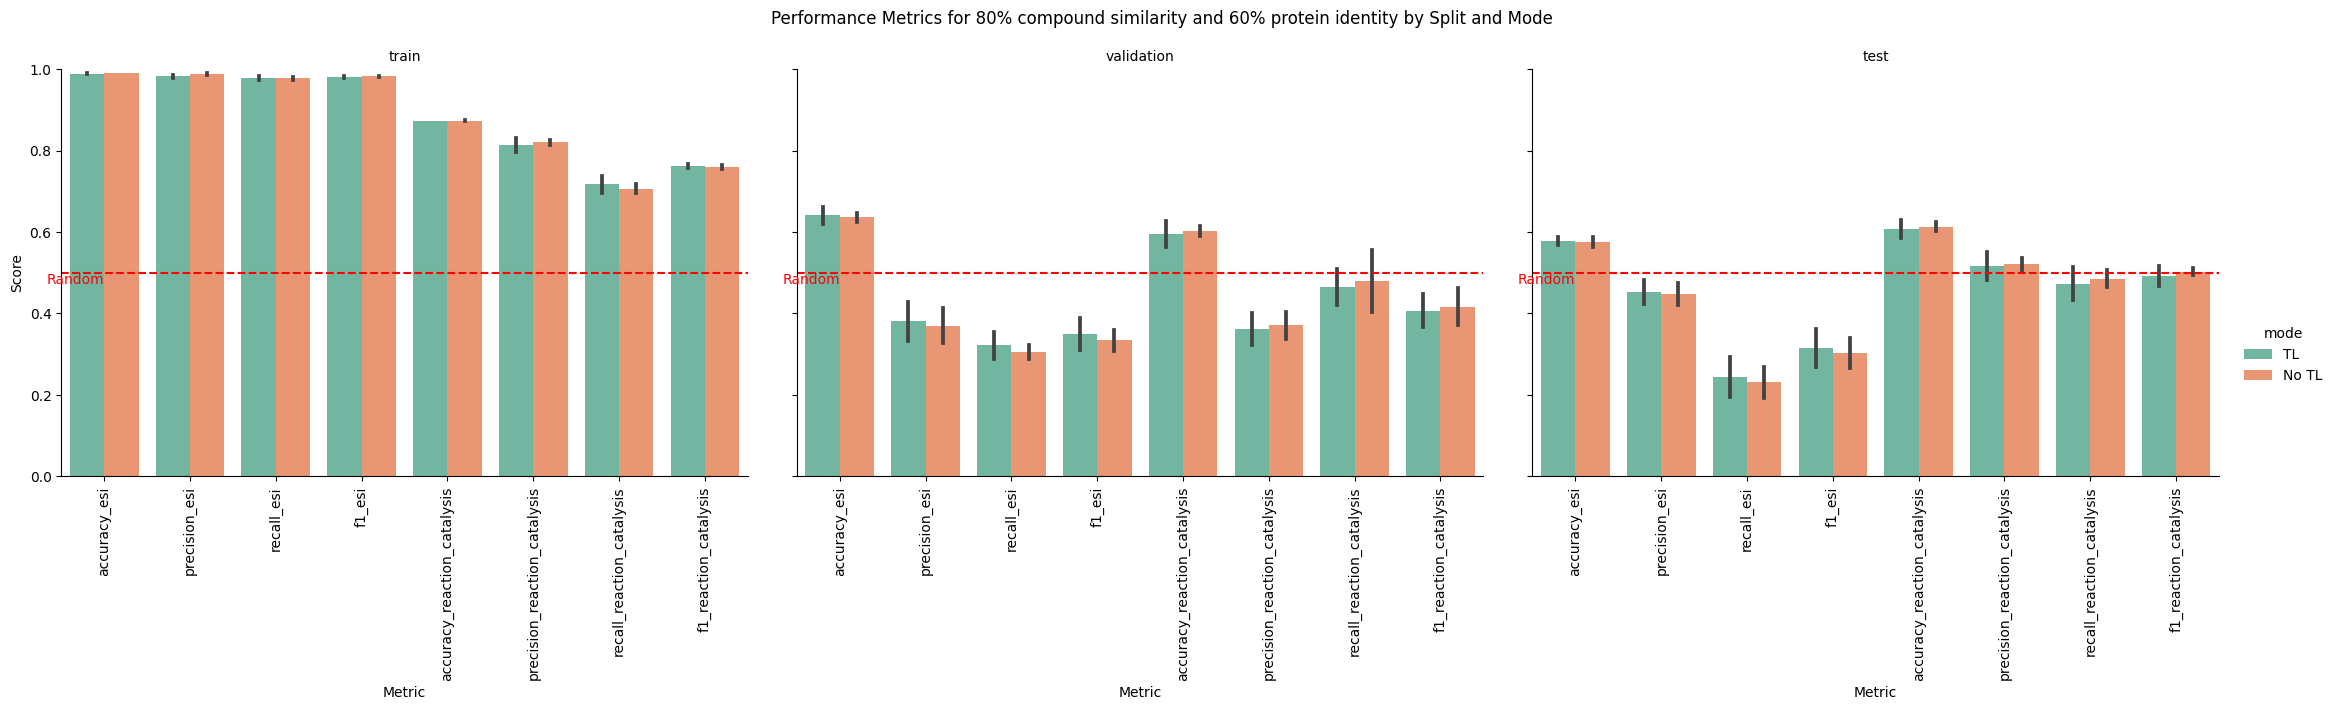

In [8]:
df.replace('0.8_60', r'80% compound similarity and 60% protein identity', inplace=True)

plot_metrics_for_model(df, model_name=r'80% compound similarity and 60% protein identity')

/tmp/ipykernel_1219585/2557204314.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(


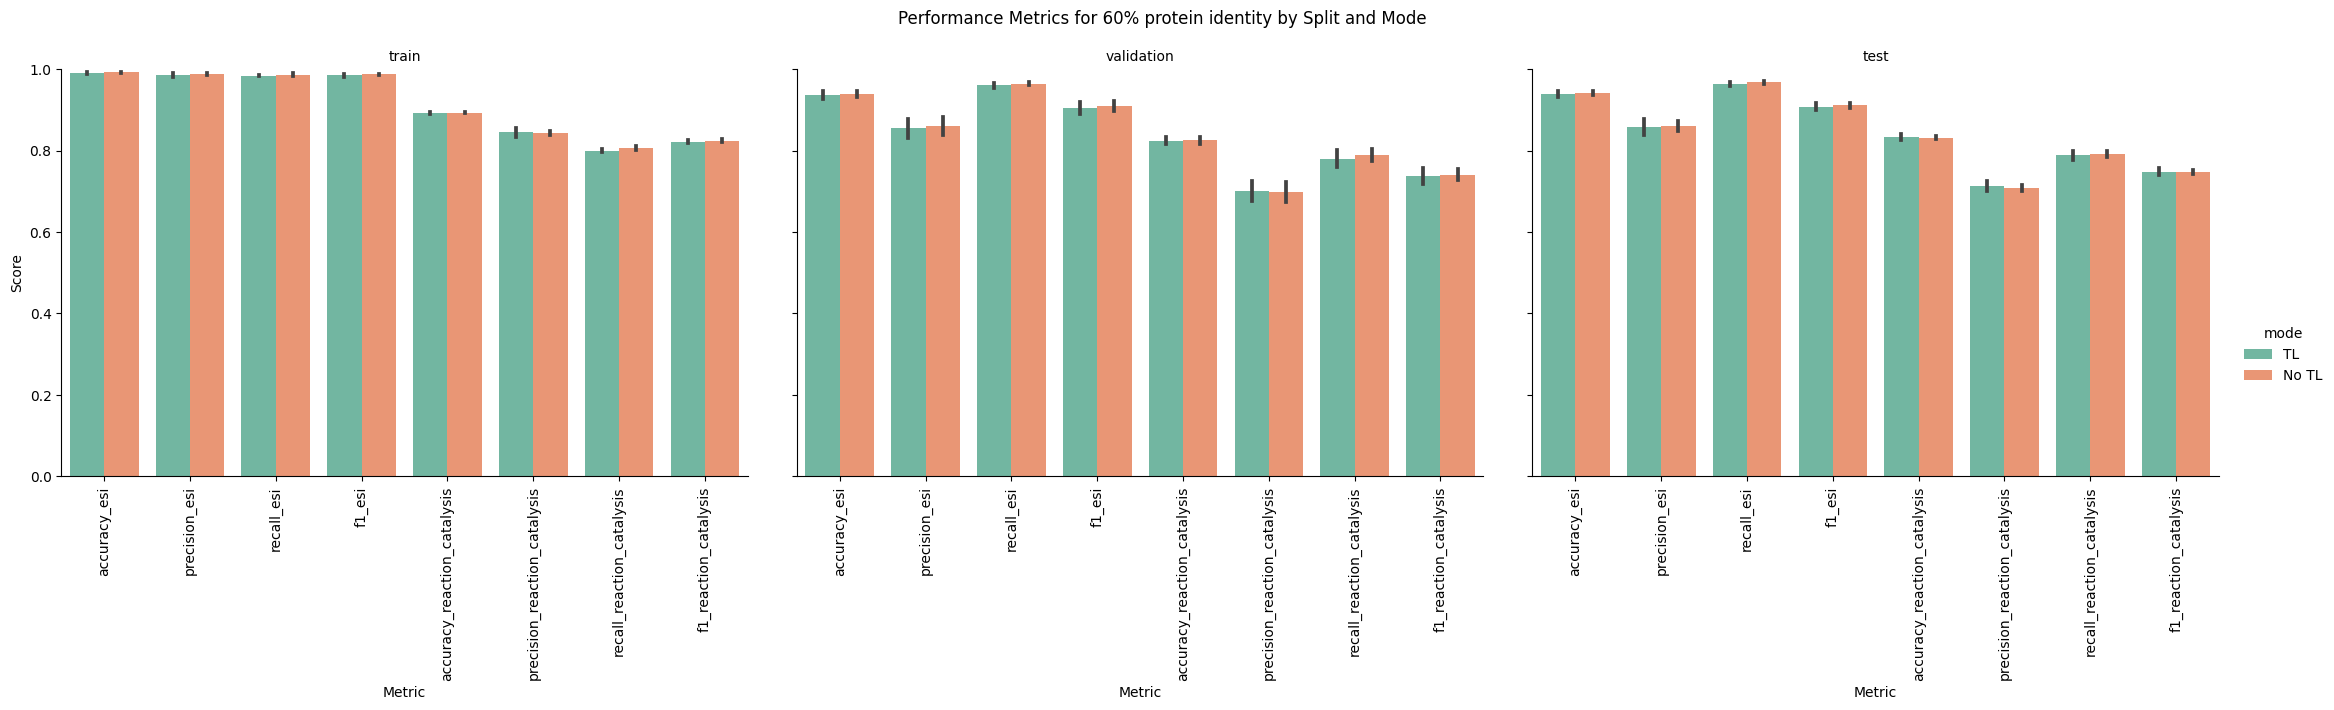

In [5]:
df.replace('1_60', r'60% protein identity', inplace=True)

plot_metrics_for_model(df, model_name=r'60% protein identity')

In [6]:
test = pd.read_csv("../splits/1_60/test_dataset.csv")
pos_count = test['interaction'].value_counts()[1]
neg_count = test['interaction'].value_counts()[0]
random_classifier_metrics(pos_count, neg_count) 

/tmp/ipykernel_1219585/3297831957.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv("../splits/1_60/test_dataset.csv")


NameError: name 'random_classifier_metrics' is not defined

<Axes: title={'center': 'Test Dataset Interaction Distribution'}>

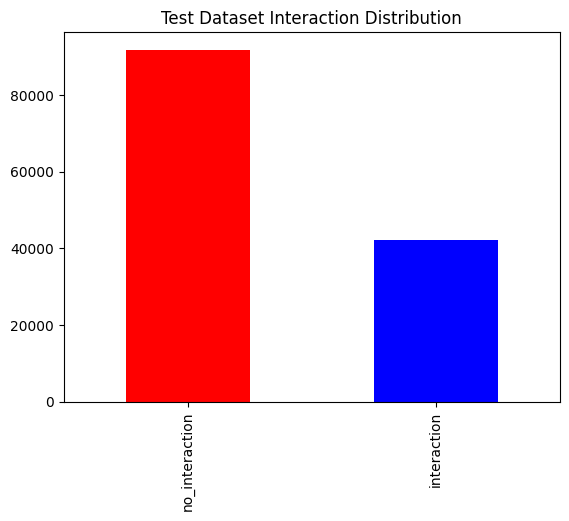

In [7]:
test['interaction'] = test['interaction'].replace({0: 'no_interaction', 1: 'interaction'})
value_counts = test['interaction'].value_counts()
# put the no interaction first
value_counts = value_counts.reindex(index=['no_interaction', 'interaction'])
value_counts.plot(kind='bar', color=['red', 'blue'], title='Test Dataset Interaction Distribution')

/tmp/ipykernel_27439/538926341.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(


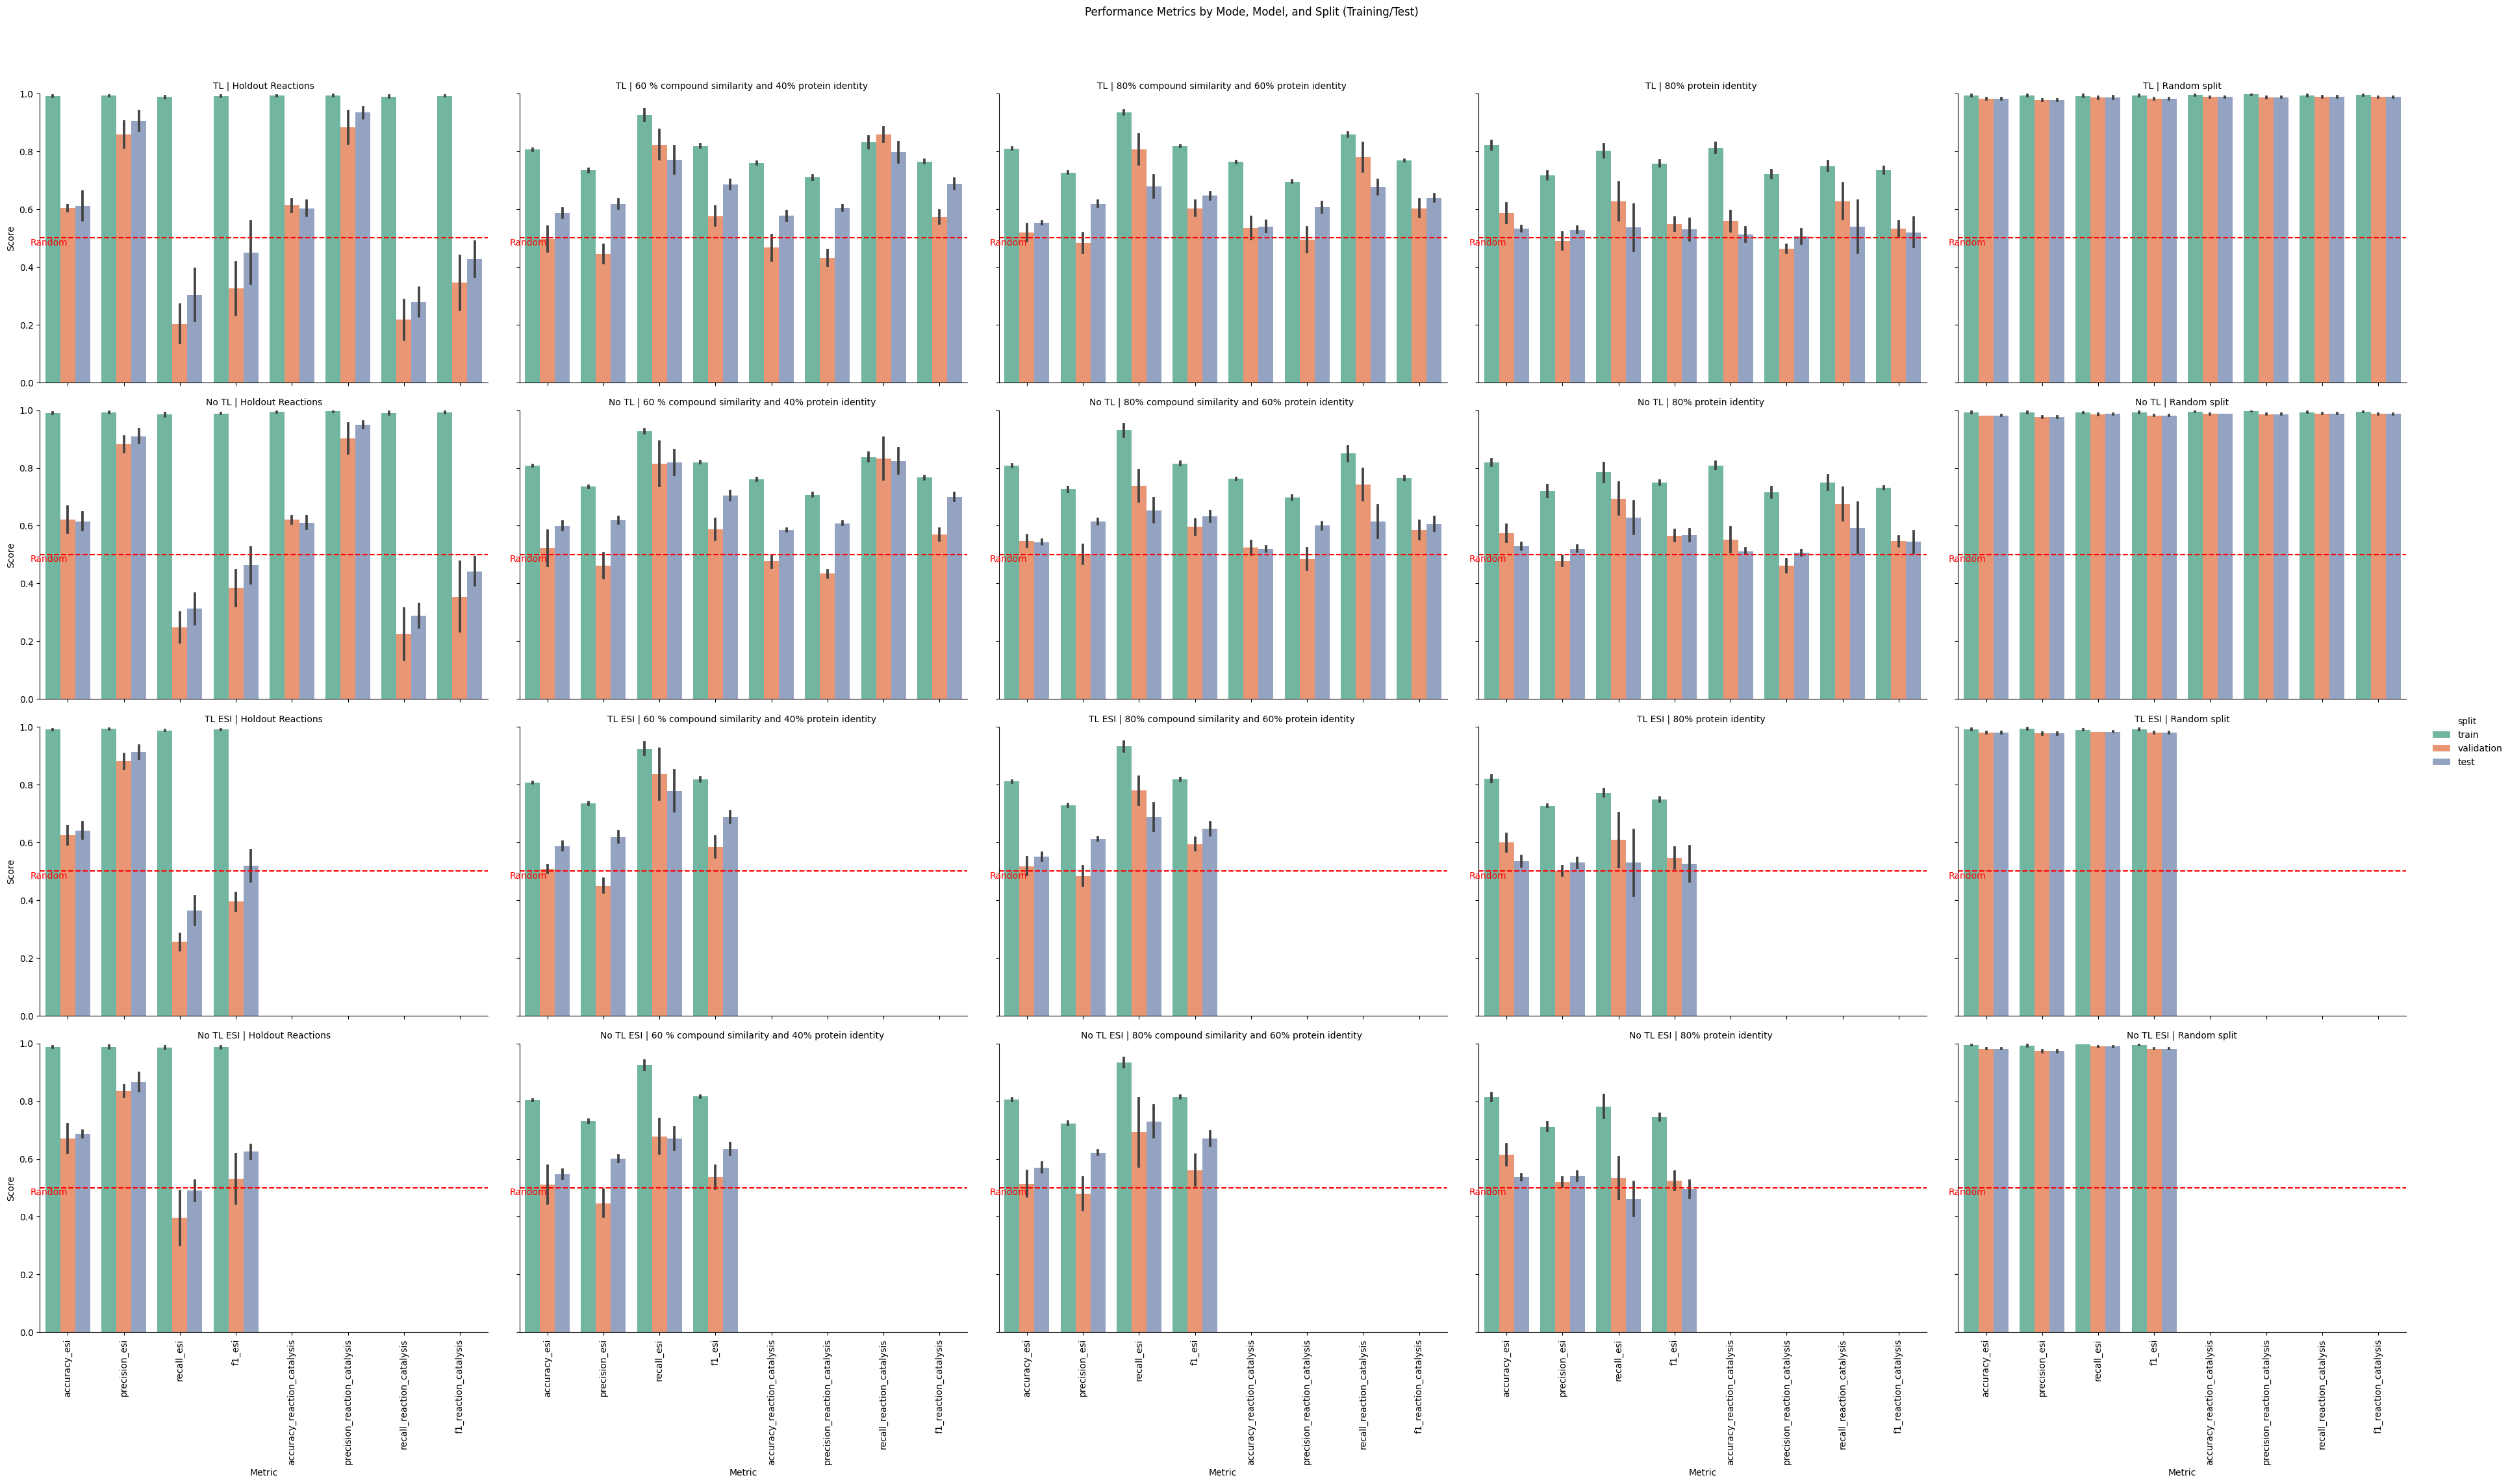

In [18]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("results_all_multi_modal_fusion.csv")
df = pd.concat([df, df_esi])

# Define metrics of interest
metrics = ['accuracy_esi', 'precision_esi', 'recall_esi', 'f1_esi',
           'accuracy_reaction_catalysis', 'precision_reaction_catalysis',
           'recall_reaction_catalysis', 'f1_reaction_catalysis']

# Melt the dataframe to have metrics in a single column
melted_df = df.melt(id_vars=['model', 'mode', 'split'], value_vars=metrics, 
                    var_name='metric', value_name='score')

# Create a facet grid with different rows for each mode and columns for each model
g = sns.catplot(
    x='metric', y='score', hue='split', col='model', row='mode',
    data=melted_df, kind='bar', height=5, aspect=1.5, palette='Set2', ci='sd'
)

# Add a horizontal line at 0.5 to represent random classifier performance
for ax in g.axes.flat:
    ax.axhline(y=0.5, color='red', linestyle='--')
    ax.text(0, 0.5, 'Random', color='red', ha='right', va='top')
    ax.set_ylim(0, 1)  # Ensure consistent y-axis limits for comparison
    ax.xaxis.set_tick_params(rotation=90)

# Title and labels
g.fig.suptitle('Performance Metrics by Mode, Model, and Split (Training/Test)', y=1.05)
g.set_axis_labels('Metric', 'Score')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

# Show plot
plt.show()


In [7]:
df

,model,mode,fold,split,accuracy_esi,precision_esi,recall_esi,f1_esi,roc_auc_esi,mcc_esi,accuracy_reaction_catalysis,precision_reaction_catalysis,recall_reaction_catalysis,f1_reaction_catalysis,roc_auc_reaction_catalysis
0,random_reaction_holdout,TL,0,train,0.990372,0.992509,0.987443,0.989970,0.990266,0.986374,0.993179,0.997527,0.988275,0.992880,0.993001
1,random_reaction_holdout,TL,0,validation,0.605742,0.912753,0.250428,0.393024,0.612772,0.326637,0.601055,0.940079,0.232086,0.372268,0.608354
2,random_reaction_holdout,TL,0,test,0.651048,0.942827,0.370880,0.532350,0.672475,0.390278,0.623317,0.963658,0.308232,0.467069,0.647415
3,random_reaction_holdout,TL,1,train,0.989651,0.991419,0.986838,0.989123,0.989526,0.980056,0.990049,0.990816,0.988293,0.989552,0.989972
4,random_reaction_holdout,TL,1,validation,0.600151,0.879764,0.215052,0.345620,0.593350,0.373161,0.644964,0.908506,0.307942,0.459974,0.639012
5,random_reaction_holdout,TL,1,test,0.639285,0.927095,0.354286,0.512661,0.661082,0.378648,0.626576,0.923962,0.329838,0.486134,0.649271
6,random_reaction_holdout,TL,2,train,0.991027,0.991404,0.988536,0.989968,0.990792,0.984873,0.992516,0.994592,0.988665,0.991620,0.992152
7,random_reaction_holdout,TL,2,validation,0.591031,0.874957,0.273522,0.416760,0.614346,0.313791,0.586246,0.913089,0.249194,0.391533,0.610996
8,random_reaction_holdout,TL,2,test,0.646898,0.916950,0.374566,0.531868,0.667726,0.368226,0.615096,0.939227,0.300714,0.455568,0.639140
9,random_reaction_holdout,TL,3,train,0.991015,0.993171,0.986995,0.990073,0.990676,0.983996,0.992060,0.994761,0.987713,0.991224,0.991694
